In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader

from hanon.data import (
    PairedImageDataset,
    gaussian_blur,
    load_lfw_images,
    normalize_to_uint8_range,
    to_tensor,
)
from hanon.training import train_one_epoch

# Use the GPU when available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("GPU available: ", torch.cuda.is_available())

# Directory where the dataset is cached
save_dir = "Data"

GPU available:  True


# 1. Data Loading

Load the LFW (Labeled Faces in the Wild) dataset. The dataset will be cached locally to avoid repeated downloads.

In [2]:
# Downloaded once, then cached locally (see hanon.data.load_lfw_images)
img = load_lfw_images(save_dir)

Image dataset loaded from cache.


# 2. Image Preprocessing

Convert images to normalized grayscale values (0-255 range) for consistent processing.

In [3]:
# Rescale every image to the usual 0-255 grayscale range
img_grayscale = np.array([normalize_to_uint8_range(image) for image in img])

# 3. Data Augmentation - Adding blur

Blur clean images to create training pairs (blurred → clean) for the deblurring model.

In [4]:
# Build the training pairs: each clean image gets a blurred counterpart
img_blurred = np.array([gaussian_blur(image, sigma=1) for image in img_grayscale])

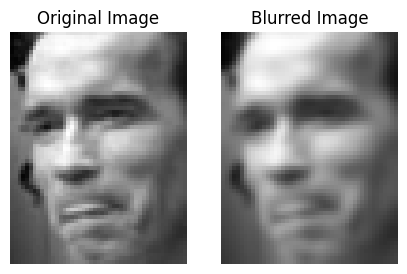

In [5]:
# Visualize the effect of the blur on a sample image
plt.figure(figsize=(5, 5))

plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(img_grayscale[1], cmap='gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Blurred Image")
plt.imshow(img_blurred[1], cmap='gray')
plt.axis('off')

plt.show()

# 4. Data Preparation for Training

Create PyTorch datasets and dataloaders with appropriate transformations.

In [6]:
# Hold out the last images for evaluation
train_data = img_blurred[:1500]
train_targets = img_grayscale[:1500]

test_data = img_blurred[1500:]
test_targets = img_grayscale[1500:]

train_dataset = PairedImageDataset(
    train_data, train_targets, transform=to_tensor, target_transform=to_tensor
)
test_dataset = PairedImageDataset(
    test_data, test_targets, transform=to_tensor, target_transform=to_tensor
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# 5. DnCNN Model Architecture

## Residual Learning Approach

Instead of predicting the clean image directly, DnCNN learns to predict the **blur pattern**:
- Traditional: `model(blurred) → clean`
- DnCNN: `model(blurred) → blur`, then `clean = blurred - predicted_blur`

## Network Architecture

1. Conv(3×3, 64) + ReLU
2. 15× [Conv(3×3, 64) + BatchNorm + ReLU]
3. Conv(3×3, 128) + BatchNorm + ReLU  
4. 3× [Conv(3×3, 128) + BatchNorm + ReLU]
5. Conv(3×3, 64) + BatchNorm + ReLU
6. Conv(3×3, 1) → outputs predicted blur

In [7]:
# DnCNN variant with a wider middle section, outputs the predicted blur residual
layers = []

# Input layer: Conv(3x3, 64 filters) + ReLU
layers.append(nn.Conv2d(1, 64, kernel_size=3, padding=1))
layers.append(nn.ReLU(inplace=True))

# 15 intermediate layers: Conv(3x3, 64) + BatchNorm + ReLU
for _ in range(15):
    layers.append(nn.Conv2d(64, 64, kernel_size=3, padding=1))
    layers.append(nn.BatchNorm2d(64))
    layers.append(nn.ReLU(inplace=True))

# Wider section: 4 layers of Conv(3x3, 128) + BatchNorm + ReLU
layers.append(nn.Conv2d(64, 128, kernel_size=3, padding=1))
layers.append(nn.BatchNorm2d(128))
layers.append(nn.ReLU(inplace=True))

for _ in range(3):
    layers.append(nn.Conv2d(128, 128, kernel_size=3, padding=1))
    layers.append(nn.BatchNorm2d(128))
    layers.append(nn.ReLU(inplace=True))

# Back down to 64 filters
layers.append(nn.Conv2d(128, 64, kernel_size=3, padding=1))
layers.append(nn.BatchNorm2d(64))
layers.append(nn.ReLU(inplace=True))

# Output layer: Conv(3x3, 1 filter) -> predicted blur, same shape as the input
layers.append(nn.Conv2d(64, 1, kernel_size=3, padding=1))

cnn = nn.Sequential(*layers).to(device)

loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(cnn.parameters(), lr=1e-3)

# 6. Model Training

Train the DnCNN model for 50 epochs and visualize the training loss progression.

Epoch 50/50
Training completed! Final loss: 0.000092


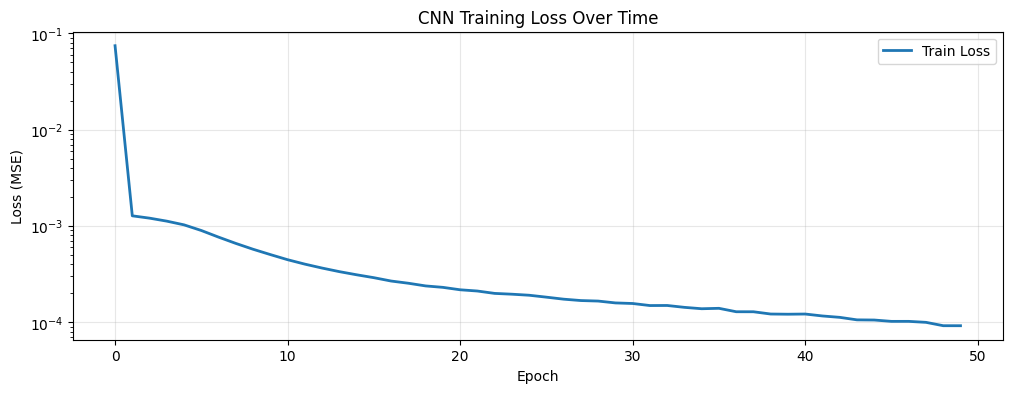

In [8]:
epochs = 50
train_losses = []

for epoch in range(epochs):
    print(f"Epoch {epoch + 1}/{epochs}", end="\r")
    train_losses.append(train_one_epoch(train_loader, cnn, loss_fn, optimizer, device))

print(f"\nTraining completed! Final loss: {train_losses[-1]:.6f}")

# Plot training loss curve
plt.figure(figsize=(12, 4))
plt.semilogy(train_losses, label='Train Loss', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('CNN Training Loss Over Time')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 7. Model Evaluation

Test the trained DnCNN model on an image.

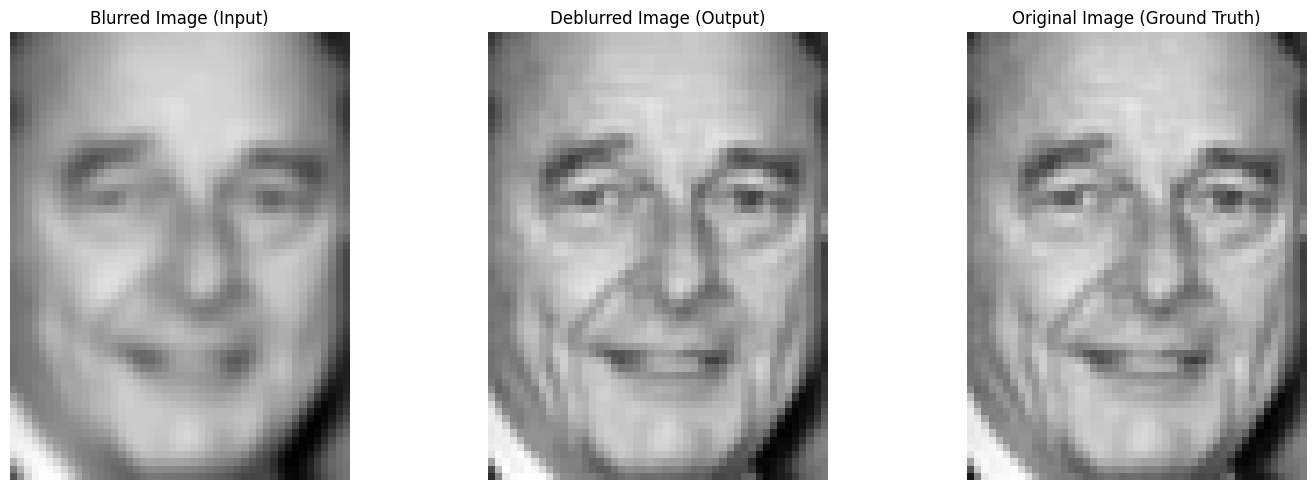

In [9]:
# Pick an image from the held-out test split
idx = 1516

cnn.eval()
with torch.no_grad():
    blurred_input = to_tensor(img_blurred[idx]).unsqueeze(0).to(device)

    # Predict the blur residual, then subtract it from the input
    blur_pred = cnn(blurred_input)
    deblurred = torch.clamp(blurred_input - blur_pred, 0, 1).cpu().squeeze()

# Visualize: blurred input, model output, ground truth
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_blurred[idx], cmap='gray')
plt.title("Blurred Image (Input)")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(deblurred, cmap='gray')
plt.title("Deblurred Image (Output)")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img_grayscale[idx], cmap='gray')
plt.title("Original Image (Ground Truth)")
plt.axis('off')

plt.tight_layout()
plt.show()

# 8. Save the model

In [10]:
# Save the full model (architecture + weights)
torch.save(cnn, 'CNN/Blur_cnn_model.pth')